# Species, Genus and Family results for all datasets

## Python imports

In [1]:
import Common
import matplotlib.pyplot as pyplt
import os.path
import pandas as pd

## Read auxilliary file containing association of species to genus and family

In [2]:
genus_family_data = pd.read_csv('../species_genus_family.tsv', sep='\t')
genus_family_data.set_index('species',inplace=True)
genus_family_data

,genus,family
species,,
Acacia dealbata,Acacia,Fabaceae
Acacia longifolia,Acacia,Fabaceae
Acacia mearnsii,Acacia,Fabaceae
Acacia melanoxylon,Acacia,Fabaceae
Acacia pycnantha,Acacia,Fabaceae
...,...,...
Xeranthemum inapertum,Xeranthemum,Asteraceae
Zannichellia palustris,Zannichellia,Potamogetonaceae
Zantedeschia aethiopica,Zantedeschia,Araceae


## Read model labels

Note that labels are not ordered alphabetically. The order corresponds to the index of the TFLite output layer per each species.

In [3]:
model_index_to_species = Common.read_floralens_model_labels()

## Compute species, genus, and family results

Uncomment lines at the end to re-generate the output files.

In [4]:
# Function to generate genus and family results for a dataset
def generate_genus_and_family_results(dataset_name, output_prefix=None):  
    species_results = []
    genus_results = []
    family_results = []
    if output_prefix == None:
        output_prefix = dataset_name
    dataset_path = '../' + dataset_name + '/'
    data = pd.read_csv(dataset_path + dataset_name + '_dataset.tsv', sep='\t')
    if dataset_name == 'floralens':
        data = data[data.set == 'TEST']
    Common.unzip_archive(dataset_path + "detailed-results.zip")
    for img in data.itertuples(): 
        #print()
        # Read score vector for image (results for all species, not just top 5)
        img_score_file = 'detailed-results/' + img.filename + '.score.txt'
        if not os.path.exists(img_score_file):
            #print('r',img.filename)
            species_scores = tflite_model.predict([dataset_path + 'images/' + img.filename]) 
            with open(img_score_file, 'w') as out:
                for s in species_scores:
                    print(s, file=out)
        species_scores = [ float(s.strip()) for s in open(img_score_file, 'r').readlines() ]
        # Calculate scores for each genus and family
        genus_scores = { }
        family_scores = { }
        for idx, score_for_idx in enumerate(species_scores):
            species_for_idx = model_index_to_species[idx]
            # Consider score_for_idx for corresponding genus
            genus_for_idx = genus_family_data['genus'][species_for_idx]
            genus_scores[genus_for_idx] = genus_scores.get(genus_for_idx, 0.0) + score_for_idx
            # Consider score_for_idx for corresponding family
            family_for_idx = genus_family_data['family'][species_for_idx]
            family_scores[family_for_idx] = family_scores.get(family_for_idx, 0.0) + score_for_idx
        #print(genus_scores)
        #print(family_scores)
        # Get top 5 scores for genus 
        #if len(genus_results) % 100 == 0:
        #    print(len(genus_results))
        sorted_sscores = [ (model_index_to_species[idx],score_for_idx) for (idx, score_for_idx) in enumerate(species_scores) ]
        sorted_sscores.sort(key=lambda x: -x[1])
        species_results.append([
            img.filename, # filename
            img.species,  # Ground truth species
            sorted_sscores[0][0], sorted_sscores[0][1], # Rank 1 and corresponding score
            sorted_sscores[1][0], sorted_sscores[1][1], # Rank 2 and corresponding score
            sorted_sscores[2][0], sorted_sscores[2][1], # Rank 3 and corresponding score
            sorted_sscores[3][0], sorted_sscores[3][1], # Rank 4 and corresponding score
            sorted_sscores[4][0], sorted_sscores[4][1]  # Rank 5 and corresponding score
        ]
        )
        sorted_gscores = [ (g,s) for g,s in genus_scores.items() ]
        sorted_gscores.sort(key=lambda x: -x[1])
        genus_results.append([
            img.filename, # filename
            genus_family_data['genus'][img.species],  # Ground truth genus
            sorted_gscores[0][0], sorted_gscores[0][1], # Rank 1 and corresponding score
            sorted_gscores[1][0], sorted_gscores[1][1], # Rank 2 and corresponding score
            sorted_gscores[2][0], sorted_gscores[2][1], # Rank 3 and corresponding score
            sorted_gscores[3][0], sorted_gscores[3][1], # Rank 4 and corresponding score
            sorted_gscores[4][0], sorted_gscores[4][1]  # Rank 5 and corresponding score
        ]
        )
        # Get top 5 scores for family
        sorted_fscores = [ (f,s) for f,s in family_scores.items() ]
        sorted_fscores.sort(key=lambda x: -x[1])
        family_results.append([
            img.filename, # filename
            genus_family_data['family'][img.species],  # Ground truth family
            sorted_fscores[0][0], sorted_fscores[0][1], # Rank 1 and corresponding score
            sorted_fscores[1][0], sorted_fscores[1][1], # Rank 2 and corresponding score
            sorted_fscores[2][0], sorted_fscores[2][1], # Rank 3 and corresponding score
            sorted_fscores[3][0], sorted_fscores[3][1], # Rank 4 and corresponding score
            sorted_fscores[4][0], sorted_fscores[4][1]  # Rank 5 and corresponding score
        ]
        )
        if len(family_results) % 1000 == 0: 
            print(len(family_results))
    species_df = pd.DataFrame(species_results, columns=[
                                     'filename', 'species', 
                                     'rank1', 'c1', 
                                     'rank2', 'c2', 
                                     'rank3', 'c3', 
                                     'rank4', 'c4', 
                                     'rank5', 'c5', 
                                    ])
    species_df.to_csv(dataset_path + dataset_name + '_floralens.tsv',sep='\t', index=False)

    genus_df = pd.DataFrame(genus_results, columns=[
                                     'filename', 'genus', 
                                     'rank1', 'c1', 
                                     'rank2', 'c2', 
                                     'rank3', 'c3', 
                                     'rank4', 'c4', 
                                     'rank5', 'c5', 
                                    ])
    genus_df.to_csv(dataset_path + output_prefix + '_genus_floralens.tsv',sep='\t', index=False)

    family_df = pd.DataFrame(family_results, columns=[
                                     'filename', 'family', 
                                     'rank1', 'c1', 
                                     'rank2', 'c2', 
                                     'rank3', 'c3', 
                                     'rank4', 'c4', 
                                     'rank5', 'c5'
                                    ])
    family_df.to_csv(dataset_path + output_prefix + '_family_floralens.tsv',sep='\t', index=False)
    Common.cleanup_dir("detailed-results")

    return genus_df,family_df,species_df

# Uncomment the following lines if necessary to generate result files
#gdf,fdf,sdf = 
#print('FLTS')
#generate_genus_and_family_results('floralens','flts')
#print('PlantCLEF')
#generate_genus_and_family_results('plantclef')
#print('Wikipedia')
#generate_genus_and_family_results('wikipedia')


## Derive results to plot

In [10]:
dataset_to_path_prefix = {
    'FLTS': '../floralens/flts',
    'PlantCLEF': '../plantclef/plantclef',
    'Wikipedia': '../wikipedia/wikipedia'
}
results = { 
    'species': [],
    'genus': [],
    'family': []
}
for dataset_name in dataset_to_path_prefix.keys():
    prefix = dataset_to_path_prefix[dataset_name]
    sdf = pd.read_csv(prefix + '_floralens.tsv', sep='\t')
    gdf = pd.read_csv(prefix + '_genus_floralens.tsv', sep='\t')
    fdf = pd.read_csv(prefix + '_family_floralens.tsv', sep='\t')
    
    stop1 = Common.top1(sdf)
    stop5 = Common.top5(sdf)
    smrr = Common.mrr(sdf)
    
    gtop1 = Common.top1(gdf, ground_truth_col='genus')
    gtop5 = Common.top5(gdf, ground_truth_col='genus')
    gmrr = Common.mrr(gdf, ground_truth_col='genus')
    
    ftop1 = Common.top1(fdf, ground_truth_col='family')
    ftop5 = Common.top5(fdf, ground_truth_col='family')
    fmrr = Common.mrr(fdf, ground_truth_col='family')

    results['species'].append([dataset_name, stop1, stop5, smrr])
    results['genus'].append(  [dataset_name, gtop1, gtop5, gmrr])
    results['family'].append( [dataset_name, ftop1, ftop5, fmrr])

  

## Auxiliary function to derive individual plots

In [11]:
font = {'family' : 'normal',
        'size'   : 12}
pyplt.rc('font', **font)
pyplt.rcParams["figure.figsize"] = (6,6)

def make_plot(data,filename):
  df = pd.DataFrame(data,columns=['Dataset', 'Top-1', 'Top-5', 'MRR'])
  plt = df.plot.bar(x='Dataset',y=['Top-1', 'Top-5', 'MRR'],color=['black','darkgray','lightgray'],width=0.9)
  plt.legend(loc='upper left', ncol=3)
  plt.set_ylim([0.60,1.0])
  plt.set_xlabel('')
  plt.set_yticks([0.60,0.70,0.80,0.90,1.0])
  plt.grid(axis='y')
  #plt.invert_yaxis()
  plt.set_xticklabels(['FLTS','PlantCLEF','Wikipedia'], rotation=0, ha='center')
  for container in plt.containers:
    plt.bar_label(container,fmt='%.2f')
  plt.get_figure().tight_layout()
  plt.get_figure().savefig(filename)
  return df


## Species results and plot

,Dataset,Top-1,Top-5,MRR
0,FLTS,0.668495,0.861240,0.745110
1,PlantCLEF,0.651400,0.837800,0.726385
2,Wikipedia,0.647668,0.837158,0.724587


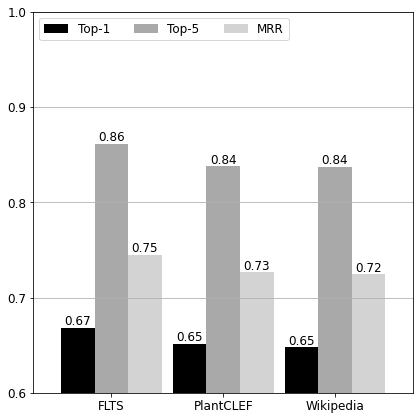

In [12]:
make_plot(results['species'],'plot_images/sgf_species.pdf')

## Genus results and plot

,Dataset,Top-1,Top-5,MRR
0,FLTS,0.759571,0.905143,0.817492
1,PlantCLEF,0.743500,0.888200,0.800787
2,Wikipedia,0.785344,0.909697,0.834999


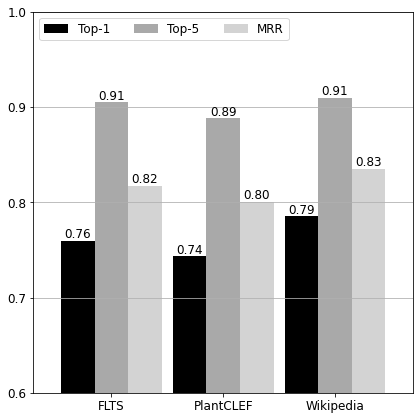

In [8]:
make_plot(results['genus'],'plot_images/sgf_genus.pdf')

## Family results and plot

,Dataset,Top-1,Top-5,MRR
0,FLTS,0.829768,0.954666,0.879989
1,PlantCLEF,0.809400,0.938600,0.861087
2,Wikipedia,0.871207,0.957809,0.906612


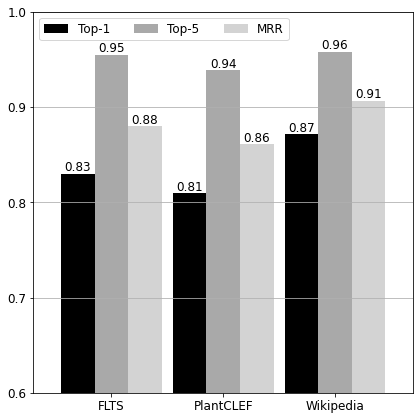

In [9]:
make_plot(results['family'],'plot_images/sgf_family.pdf')